# a) Cara Kerja Arsitektur Generative Adversarial Network (GAN)

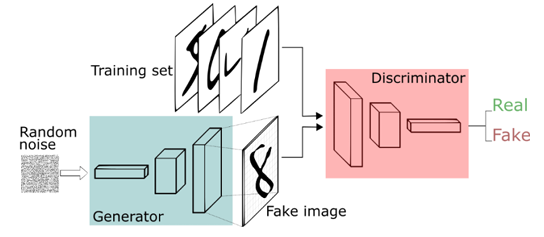

GAN terdiri dari dua neural network yang saling berkompetisi dalam sebuah proses yang disebut adversarial training. Kedua komponen utamanya adalah Generator dan Discriminator. 

**Komponen dan Alur Kerja**
1. **Generator (Pemalsu)**  
Generator menerima input berupa random noise, yaitu sebuah vektor acak dari distribusi tertentu (misalnya distribusi Gaussian atau uniform). Dari noise yang tidak bermakna ini, Generator berusaha menghasilkan data sintetis (fake image) yang menyerupai data asli dari training set. Secara arsitektur, Generator biasanya terdiri dari lapisan-lapisan transposed convolution (atau deconvolution) yang secara bertahap meng-upsample vektor berdimensi rendah menjadi sebuah gambar berdimensi penuh. Pada gambar, terlihat noise acak masuk ke Generator dan menghasilkan gambar angka "8" palsu.

2. **Discriminator (Penilai)**  
Discriminator adalah sebuah binary classifier yang menerima dua jenis input: gambar asli dari training set dan gambar palsu (fake image) yang dihasilkan oleh Generator. Tugas Discriminator adalah membedakan mana gambar yang Real (berasal dari dataset asli) dan mana yang Fake (buatan Generator). Arsitekturnya biasanya berupa CNN klasik yang menerima gambar dan menghasilkan satu nilai probabilitas (0 = fake, 1 = real).

3. **Proses Adversarial (Permainan Dua Pemain)**  
Kedua jaringan ini dilatih secara bergantian dalam sebuah minimax game:  
- **Langkah Discriminator**: Discriminator dilatih dengan menerima batch campuran gambar asli (diberi label "Real") dan gambar palsu dari Generator (diberi label "Fake"). Discriminator memperbarui bobotnya agar semakin akurat membedakan keduanya.
- **Langkah Generator**: Generator dilatih dengan menghasilkan gambar palsu lalu meneruskannya ke Discriminator. Generator memperbarui bobotnya berdasarkan feedback dari Discriminator, tujuannya adalah memaksimalkan peluang Discriminator salah mengklasifikasikan gambar palsu sebagai "Real". Penting dicatat bahwa pada langkah ini, bobot Discriminator dibekukan (frozen) dan hanya bobot Generator yang diperbarui.

Proses ini diulang terus-menerus hingga tercapai kondisi *Nash Equilibrium*, yaitu ketika Generator menghasilkan gambar yang begitu realistis sehingga Discriminator tidak bisa lagi membedakan gambar asli dan palsu (probabilitas output ≈ 0.5 untuk kedua jenis input).  

Jika dianalogikan sebagai pemalsu uang dan polisi, Generator berperan sebagai pemalsu uang yang terus belajar membuat uang palsu yang semakin mirip dengan aslinya. Discriminator berperan sebagai polisi yang terus belajar mendeteksi uang palsu.

Pada awal pelatihan, pemalsu masih sangat buruk dimana uang palsunya mudah dikenali. Polisi pun mudah membedakannya. Namun seiring waktu, pemalsu belajar dari kegagalannya dan membuat uang palsu yang semakin sempurna. Polisi pun harus terus meningkatkan kemampuan deteksinya. Kompetisi ini terus berlanjut hingga akhirnya pemalsu menjadi begitu mahir sehingga uang palsunya nyaris tidak bisa dibedakan dari yang asli, bahkan polisi terbaik pun hanya bisa menebak secara acak (50-50).

**Fungsi Objektif (Loss Function)**  
Secara matematis, pelatihan GAN dirumuskan sebagai minimax optimization:
$$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log (1 - D(G(z)))]$$

- **Suku pertama:** Discriminator ingin memaksimalkan $\log D(x)$, artinya memberikan probabilitas tinggi (mendekati 1) untuk data asli $x$

- **Suku kedua:** Discriminator ingin memaksimalkan $\log(1 - D(G(z)))$, artinya memberikan probabilitas rendah (mendekati 0) untuk data palsu $G(z)$.

- **Tujuan Generator:** Generator berusaha meminimalkan suku kedua tersebut dengan membuat $D(G(z))$ mendekati 1, sehingga Discriminator tertipu dan menganggap data palsu sebagai data asli.

**Ringkasan Alur pada Gambar**    
1) Random noise masuk ke Generator  
2) Generator menghasilkan fake image  
3) Fake image bersama gambar asli dari training set masuk ke Discriminator  
4) Discriminator mengklasifikasikan setiap input sebagai Real atau Fake  
5) Error dari klasifikasi digunakan untuk memperbarui bobot kedua jaringan secara bergantian  
6) Proses berulang hingga Generator menghasilkan gambar yang tidak bisa dibedakan dari data asli

In [ ]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from scipy.linalg import sqrtm

import random

np.random.seed(42)
tf.random.set_seed(42)

2026-06-29 19:13:16.012417: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782760396.205004      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782760396.259771      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782760396.695142      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782760396.695181      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782760396.695184      58 computation_placer.cc:177] computation placer alr

# b) Arsitektur GAN

## Loading & Preprocessing Data

In [ ]:
hits = glob.glob('/kaggle/input/**/train/car', recursive=True)
assert hits, "folder train/car not found"
BASE = os.path.dirname(os.path.dirname(hits[0]))
print('BASE =', BASE, '| isi:', os.listdir(BASE))

CLASSES     = ['car', 'plane']
CLASS_NAMES = ['Car', 'Plane'] 
IMG_SIZE    = 28
IMG_DIM     = IMG_SIZE * IMG_SIZE   
n_classes   = 2
latent_dim  = 100

BASE = /kaggle/input/datasets/datamunge/overheadmnist/version2 | isi: ['classes.csv', 'train.csv', 'test.csv', 'data', 'test', 'train', 'labels.csv']


In [ ]:
def load_split(split):
    X, y = [], []
    for label, cls in enumerate(CLASSES):
        paths = sorted(glob.glob(os.path.join(BASE, split, cls, '*.jpg')))
        print(f'{split}/{cls:5s}: {len(paths)} gambar (label={label})')
        for p in paths:
            img = Image.open(p).convert('L').resize((IMG_SIZE, IMG_SIZE))
            X.append(np.array(img, dtype=np.float32))
            y.append(label)
    return np.array(X), np.array(y, dtype=np.int32)

X_train_raw, y_train = load_split('train')
X_test_raw,  y_test  = load_split('test')
print('Train:', X_train_raw.shape, '| Test:', X_test_raw.shape)

train/car  : 7116 gambar (label=0)
train/plane: 7124 gambar (label=1)
test/car  : 896 gambar (label=0)
test/plane: 888 gambar (label=1)
Train: (14240, 28, 28) | Test: (1784, 28, 28)


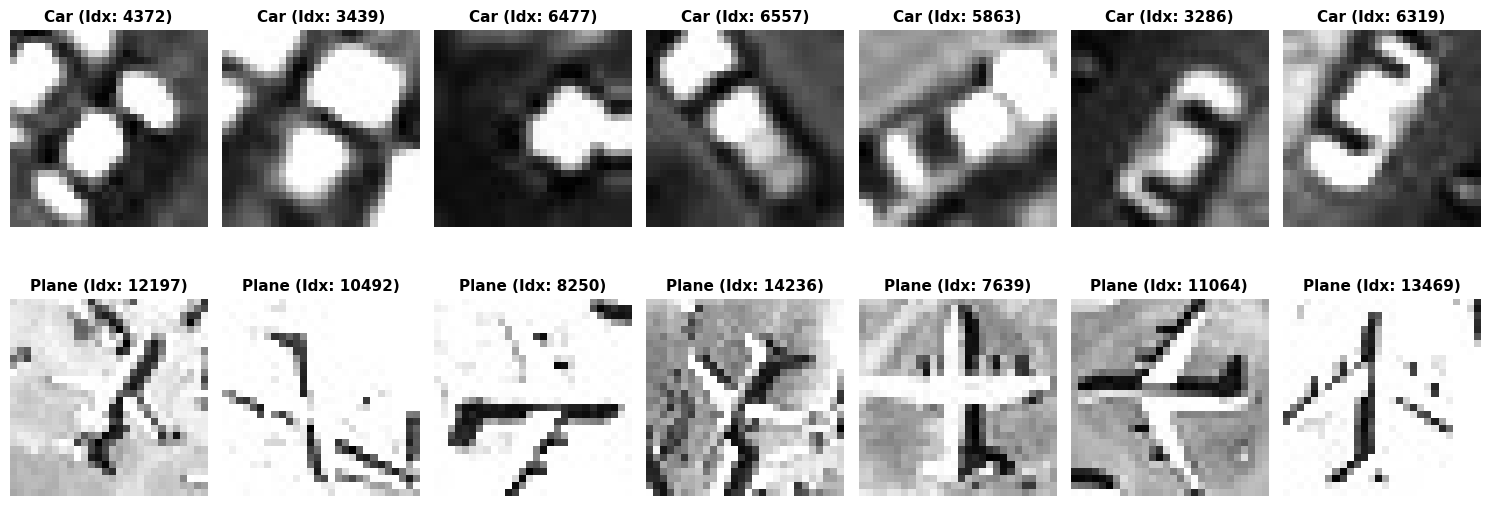

In [4]:
num_samples = 7
fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))
y_train_flat = y_train.flatten()

for row, class_name in enumerate(CLASS_NAMES):
    indices = np.where(y_train_flat == row)[0]    
    selected_indices = np.random.choice(indices, num_samples, replace=False)
    
    for col, idx in enumerate(selected_indices):
        axes[row, col].imshow(X_train_raw[idx], cmap='gray')
        if col == 0:
            axes[row, col].set_ylabel(class_name, fontsize=14, fontweight='bold')
        axes[row, col].set_title(f"{class_name} (Idx: {idx})", fontsize=11, fontweight='semibold')
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## Normalisasi dan Persiapan Data Baseline
Data gambar dinormalisasi ke rentang **[-1, 1]** agar cocok dengan fungsi aktivasi `tanh` di output Generator (yang juga menghasilkan nilai [-1, 1]). Konsistensi rentang ini penting karena jika data real [0, 255], sementara output Generator [-1, 1], Discriminator bisa membedakan keduanya hanya dari rentang angka, bukan dari isi gambar.

Data di-**flatten** menjadi vektor 784 (28×28 = 784) karena arsitektur baseline menggunakan **fully-connected (MLP)** yang menerima input vektor

In [5]:
X_train_flat = (X_train_raw.reshape(len(X_train_raw), -1) / 127.5) - 1.0
X_test_flat  = (X_test_raw.reshape(len(X_test_raw),  -1) / 127.5) - 1.0
y_train = y_train.reshape(-1, 1)
y_test  = y_test.reshape(-1, 1)

base_ds = (tf.data.Dataset.from_tensor_slices((X_train_flat, y_train))
           .shuffle(len(X_train_flat), seed=42).batch(64, drop_remainder=True)
           .prefetch(tf.data.AUTOTUNE))

print('Train:', X_train_flat.shape, '| Test:', X_test_flat.shape)

I0000 00:00:1782760802.233012      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782760802.238851      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Train: (14240, 784) | Test: (1784, 784)


## Baseline
Aktivasi LeakyReLU ditambahkan sebagai aktivasi dasar agar model dapat mempelajari representasi non-linear yang kompleks dari data citra. Tanpa aktivasi non-linear, beberapa lapisan linear hanya akan bertindak sebagai satu transformasi linear, sehingga kapasitas pembelajaran model menjadi terbatas.

In [ ]:
def build_baseline_generator():
    noise = keras.Input((latent_dim,))
    label = keras.Input((1,), dtype='int32')

    # Embedding (labels)
    li = layers.Embedding(input_dim=n_classes, output_dim=n_classes)(label)
    li = layers.Flatten()(li)

    # Noise + Labels (Concatenate)
    x  = layers.Concatenate()([noise, li])
    
    # Linear(noise + n_labels, 128)
    x = layers.Dense(128)(x)
    x = layers.LeakyReLU(0.2)(x) 
    
    # Linear(128, 256)
    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(0.2)(x)
    
    # Linear(256, 512)
    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(0.2)(x)
    
    # Linear(512, 1024)
    x = layers.Dense(1024)(x)
    x = layers.LeakyReLU(0.2)(x)
    
    # Linear(1024, img_size ** 2) -> Fake Images
    out = layers.Dense(IMG_DIM, activation='tanh')(x)  
    return keras.Model([noise, label], out, name='baseline_generator')

G_base = build_baseline_generator()
G_base.summary()

Model: "baseline_generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 2)      │          4 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 2)         │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 102)       │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     13,184 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 128)       │          0 │ dense[0][0]       │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     33,024 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 256)       │          0 │ dense_1[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │    131,584 │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 512)       │          0 │ dense_2[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1024)      │    525,312 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 1024)      │          0 │ dense_3[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 784)       │    803,600 │ leaky_re_lu_3[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,506,708 (5.75 MB)

 Trainable params: 1,506,708 (5.75 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
def build_baseline_discriminator():
    img   = keras.Input((IMG_DIM,))
    label = keras.Input((1,), dtype='int32')
    
    # Embedding (labels)
    li = layers.Embedding(input_dim=n_classes, output_dim=n_classes)(label)
    li = layers.Flatten()(li)

    # Gambar + Labels (n_labels + img_size ** 2)
    x  = layers.Concatenate()([img, li])
    
    # Linear(n_labels + img_size ** 2, 512)
    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(0.2)(x)
    
    # Linear(512, 1024)
    x = layers.Dense(1024)(x)
    x = layers.LeakyReLU(0.2)(x)
    
    # Linear(1024, 1024)
    x = layers.Dense(1024)(x)
    x = layers.LeakyReLU(0.2)(x)
    
    # Linear(1024, 512)
    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(0.2)(x)

    # Linear(512, 1) -> Output Fake (0) / Real (1)
    out = layers.Dense(1)(x)                            
    return keras.Model([img, label], out, name='baseline_discriminator')

D_base = build_baseline_discriminator()
D_base.summary()

Model: "baseline_discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 2)      │          4 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 2)         │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 786)       │          0 │ input_layer_2[0]… │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 512)       │    402,944 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 512)       │          0 │ dense_5[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1024)      │    525,312 │ leaky_re_lu_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 1024)      │          0 │ dense_6[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1024)      │  1,049,600 │ leaky_re_lu_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 1024)      │          0 │ dense_7[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 512)       │    524,800 │ leaky_re_lu_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 512)       │          0 │ dense_8[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1)         │        513 │ leaky_re_lu_7[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,503,173 (9.55 MB)

 Trainable params: 2,503,173 (9.55 MB)

 Non-trainable params: 0 (0.00 B)

### Training Baseline
Fungsi `train_gan` melatih Generator dan Discriminator secara **bergantian** dalam satu loop epoch. Setiap epoch, seluruh data training dilewati sekali.

Proses per batch:
1. **Discriminator** dilatih membedakan gambar real (target = `real_target`) vs fake dari Generator (target = 0).
2. **Generator** dilatih "menipu" Discriminator agar menilai fake sebagai real (target = 1).

Loss menggunakan **Binary Cross-Entropy** dengan `from_logits=True` (sesuai output Discriminator tanpa sigmoid). History (D-loss dan G-loss per epoch) disimpan untuk visualisasi kestabilan training.

In [ ]:
def train_gan(G, D, train_ds, g_lr, d_lr, epochs,
              real_target=1.0, sample_every=10, name='GAN'):
    bce   = keras.losses.BinaryCrossentropy(from_logits=True)
    g_opt = keras.optimizers.Adam(g_lr, beta_1=0.5)
    d_opt = keras.optimizers.Adam(d_lr, beta_1=0.5)
    history = {'d_loss': [], 'g_loss': []}

    @tf.function
    def step(real_imgs, real_labels):
        bs = tf.shape(real_imgs)[0]
        
        # Discriminator
        noise = tf.random.normal((bs, latent_dim))
        gl    = tf.random.uniform((bs, 1), 0, n_classes, dtype=tf.int32)
        with tf.GradientTape() as t:
            fake   = G([noise, gl], training=True)
            d_real = D([real_imgs, real_labels], training=True)
            d_fake = D([fake, gl], training=True)
            d_loss = (bce(tf.ones_like(d_real) * real_target, d_real) +
                      bce(tf.zeros_like(d_fake), d_fake)) / 2
        d_opt.apply_gradients(zip(t.gradient(d_loss, D.trainable_variables),
                                  D.trainable_variables))
        
        # Generator
        noise = tf.random.normal((bs, latent_dim))
        gl    = tf.random.uniform((bs, 1), 0, n_classes, dtype=tf.int32)
        with tf.GradientTape() as t:
            fake2  = G([noise, gl], training=True)
            d_fake2 = D([fake2, gl], training=True)
            g_loss = bce(tf.ones_like(d_fake2), d_fake2)
        g_opt.apply_gradients(zip(t.gradient(g_loss, G.trainable_variables),
                                  G.trainable_variables))
        
        return d_loss, g_loss

    print(f"Memulai training {name}...")
    for ep in range(epochs):
        mD, mG = keras.metrics.Mean(), keras.metrics.Mean()
        for imgs, lbls in train_ds:
            d, g = step(imgs, lbls)
            mD(d); mG(g)
            
        history['d_loss'].append(float(mD.result()))
        history['g_loss'].append(float(mG.result()))
        
        if sample_every and (ep + 1) % sample_every == 0:
            print(f'[{ep+1}/{epochs}] D: {history["d_loss"][-1]:.3f} | G: {history["g_loss"][-1]:.3f}')
            
    return history

In [9]:
hist_base = train_gan(G_base, D_base, base_ds,
                      g_lr=2e-4, d_lr=2e-4, epochs=100,
                      real_target=1.0,
                      name='Baseline Architecture')

Memulai training Baseline Architecture...
[10/100] D: 0.314 | G: 2.910
[20/100] D: 0.332 | G: 2.393
[30/100] D: 0.348 | G: 2.208
[40/100] D: 0.342 | G: 2.291
[50/100] D: 0.274 | G: 2.781
[60/100] D: 0.211 | G: 3.397
[70/100] D: 0.167 | G: 4.062
[80/100] D: 0.143 | G: 4.491
[90/100] D: 0.124 | G: 4.831
[100/100] D: 0.107 | G: 4.756


### FID Score
FID mengukur **kesamaan distribusi** antara citra real (test set) dan citra generated. Semakin kecil FID, semakin mirip distribusinya yang berarti Generator menghasilkan gambar yang lebih realistis.

In [ ]:
inception = keras.applications.InceptionV3(
    include_top=False, pooling='avg', input_shape=(299, 299, 3))

def get_features_base(imgs_flat):                 
    x = ((imgs_flat + 1) / 2).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
    x = np.repeat(x, 3, axis=-1)             
    x = tf.image.resize(x, (299, 299)).numpy()
    x = keras.applications.inception_v3.preprocess_input(x * 255.0)
    return inception.predict(x, batch_size=64, verbose=0)

def fid_score(f1, f2, eps=1e-6):
    mu1, s1 = f1.mean(0), np.cov(f1, rowvar=False)
    mu2, s2 = f2.mean(0), np.cov(f2, rowvar=False)
    covmean, _ = sqrtm(s1 @ s2, disp=False)
    if not np.isfinite(covmean).all():                
        off = np.eye(s1.shape[0]) * eps
        covmean = sqrtm((s1 + off) @ (s2 + off))
    if np.iscomplexobj(covmean): covmean = covmean.real
    return float(np.sum((mu1 - mu2)**2) + np.trace(s1 + s2 - 2*covmean))
    
noise  = tf.random.normal((len(X_test_flat), latent_dim))
labels = tf.convert_to_tensor(y_test)              
fake   = G_base([noise, labels], training=False).numpy()

fid_baseline = fid_score(get_features_base(X_test_flat), get_features_base(fake))
print(f"FID (Baseline) = {fid_baseline:.2f}")

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


I0000 00:00:1782761054.169092     133 service.cc:152] XLA service 0x79d10af2d5b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782761054.169150     133 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782761054.169157     133 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782761055.395699     133 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782761071.025762     133 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


FID (Baseline) = 215.79


Didapatkan FID 215.79 untuk baseline dimana tergolong cukup tinggi, yang menunjukkan bahwa distribusi citra generated masih jauh berbeda dari distribusi citra real pada test set.

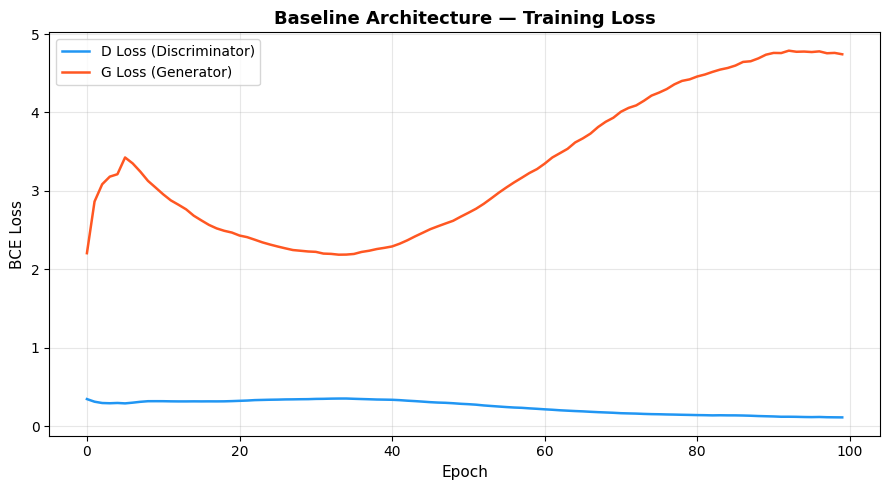

In [11]:
def plot_history(history, title, c_d='#2196F3', c_g='#FF5722'):
    w = max(1, len(history['d_loss']) // 20)        
    sm = lambda k: pd.Series(history[k]).rolling(w, min_periods=1).mean()
    
    plt.figure(figsize=(9, 5))

    plt.plot(sm('d_loss'), label='D Loss (Discriminator)', color=c_d, lw=1.8)
    plt.plot(sm('g_loss'), label='G Loss (Generator)', color=c_g, lw=1.8)
    
    plt.title(f'{title} — Training Loss', fontsize=13, fontweight='bold')
    plt.xlabel('Epoch', fontsize=11)
    plt.ylabel('BCE Loss', fontsize=11)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_history(hist_base, 'Baseline Architecture')

Berdasarkan grafik loss, nilai Discriminator Loss (D-loss) cenderung lebih rendah dibandingkan Generator Loss (G-loss) selama proses training. Kondisi ini menunjukkan bahwa Discriminator lebih mudah membedakan data real dan fake, sementara Generator masih kesulitan menghasilkan data fake yang cukup realistis untuk mengecoh Discriminator. Hal ini mengindikasikan bahwa Discriminator lebih dominan dibandingkan Generator selama proses pembelajaran.

Salah satu penyebabnya adalah penggunaan arsitektur **Multi Layer Perceptron (MLP)** yang mengubah citra menjadi vektor satu dimensi berukuran 784 piksel. Dengan pendekatan ini, Generator mempelajari setiap piksel secara terpisah tanpa mempertimbangkan hubungan spasial antar piksel. Akibatnya, pola visual yang dihasilkan cenderung kabur sehingga lebih mudah dikenali sebagai data fake oleh Discriminator.

Ketika Discriminator menjadi terlalu dominan, nilai D-loss dapat menjadi sangat rendah karena Discriminator mampu membedakan data real dan fake dengan sangat baik. Pada kondisi ini, Discriminator cenderung menjadi overconfident, yaitu memberikan prediksi dengan tingkat keyakinan yang sangat tinggi. Akibatnya, feedback atau sinyal gradien yang diterima Generator menjadi semakin kecil dan kurang informatif, sehingga proses pembelajaran Generator menjadi kurang efektif dan nilai G-loss cenderung meningkat.

Oleh karena itu, arsitektur akan dimodifikasi menjadi **Conditional Deep Convolutional Generative Adversarial Network (cDCGAN)**. Penggunaan layer Conv2D dan Conv2DTranspose memungkinkan model mempertahankan informasi spasial pada citra sehingga Generator dapat mempelajari pola lokal dan struktur visual dengan lebih baik. Dengan demikian, data fake yang dihasilkan menjadi lebih realistis dan lebih konsisten dibandingkan dengan arsitektur MLP.

Selain itu, diterapkan teknik **label smoothing** dengan mengubah target label data real dari 1.0 menjadi 0.9. Teknik ini bertujuan mengurangi kecenderungan Discriminator untuk menjadi overconfident, sehingga Discriminator tidak memberikan prediksi yang terlalu ekstrem. Dengan demikian, Generator tetap memperoleh sinyal pembelajaran yang informatif dan proses training antara Generator dan Discriminator dapat berlangsung dengan lebih seimbang.

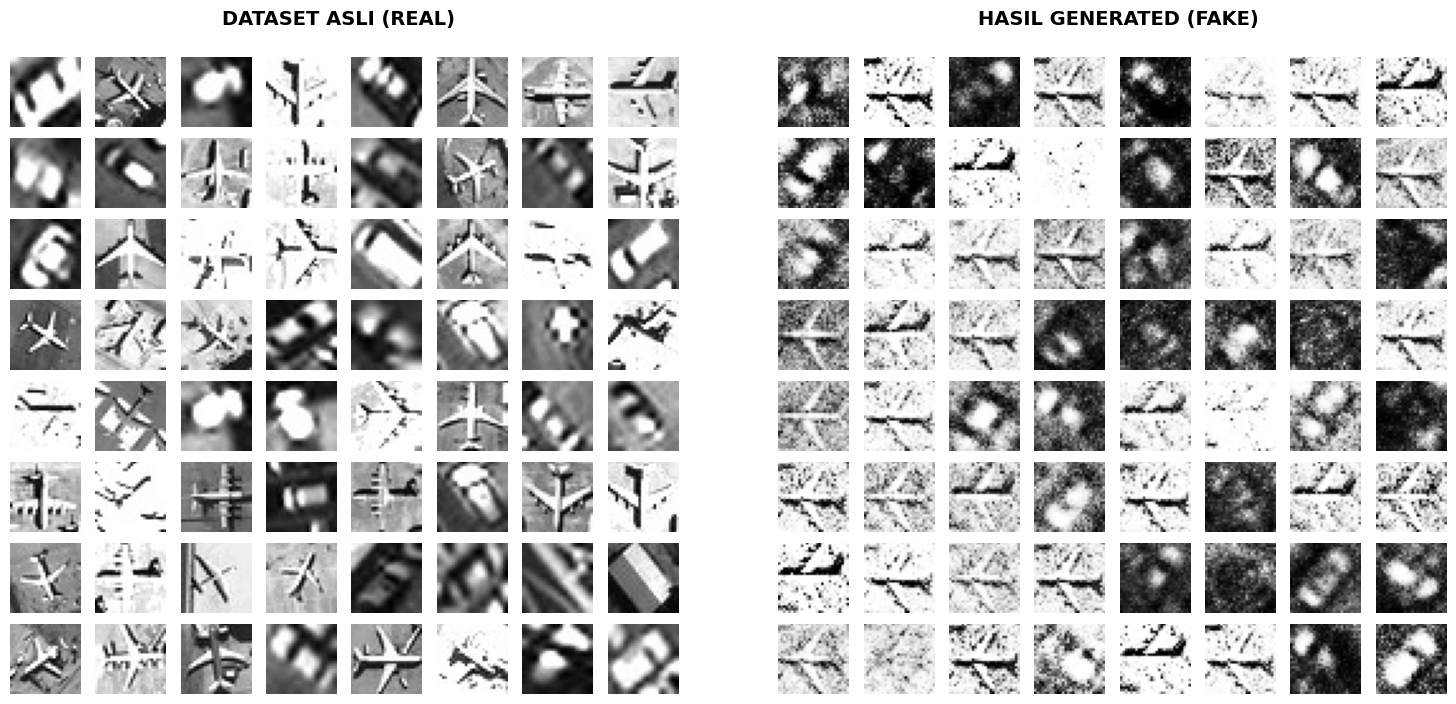

In [ ]:
grid_size = 8
n_images = grid_size * grid_size  

idx = np.random.choice(len(X_test_flat), n_images, replace=False)
real_imgs_flat = X_test_flat[idx]
real_imgs = ((real_imgs_flat + 1) / 2.0).reshape(-1, IMG_SIZE, IMG_SIZE)
real_labels = tf.convert_to_tensor(y_test[idx].reshape(-1, 1), dtype=tf.int32)

noise = tf.random.normal((n_images, latent_dim))
generated = G_base([noise, real_labels], training=False).numpy()
gen_imgs = ((generated + 1) / 2.0).reshape(-1, IMG_SIZE, IMG_SIZE)

fig, axes = plt.subplots(grid_size, grid_size * 2 + 1, figsize=(15, 7.5))
fig.text(0.24, 0.95, 'DATASET ASLI (REAL)', ha='center', va='center', fontsize=14, fontweight='bold')
fig.text(0.76, 0.95, 'HASIL GENERATED (FAKE)', ha='center', va='center', fontsize=14, fontweight='bold')

for i in range(n_images):
    row = i // grid_size
    col = i % grid_size
    
    ax_real = axes[row, col]
    ax_real.imshow(real_imgs[i], cmap='gray')
    ax_real.axis('off')
    
    ax_gen = axes[row, col + grid_size + 1]
    ax_gen.imshow(gen_imgs[i], cmap='gray')
    ax_gen.axis('off')

for row in range(grid_size):
    axes[row, grid_size].axis('off')

plt.subplots_adjust(top=0.90, bottom=0.05, left=0.02, right=0.98, hspace=0.15, wspace=0.15)
plt.show()

Gambar hasil generate model tampak cukup buram jika dibandingkan dengan data asli di sebelah kiri. Hal ini menunjukkan model baseline belum mampu menghasilkan citra yang realistis karena Generator kesulitan mempelajari distribusi data dengan baik, yang kemungkinan disebabkan oleh Discriminator yang terlalu dominan selama proses training.

# c) Modification
Data yang sebelumnya flat (784) di-reshape ke bentuk gambar **(N, 28, 28, 1)** karena Conv2D membutuhkan input 2D, berbeda dari Dense yang menerima vektor. 

In [13]:
X_train_img = X_train_flat.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
X_test_img  = X_test_flat.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
print('Modification input:', X_train_img.shape, '| test:', X_test_img.shape)

modif_ds = (tf.data.Dataset.from_tensor_slices((X_train_img, y_train))
            .shuffle(len(X_train_img), seed=42)
            .batch(64, drop_remainder=True)
            .prefetch(tf.data.AUTOTUNE))

Modification input: (14240, 28, 28, 1) | test: (1784, 28, 28, 1)


In [ ]:
def build_modif_generator():
    noise = keras.Input((latent_dim,))
    label = keras.Input((1,), dtype='int32')
    li = layers.Embedding(input_dim=n_classes, output_dim=n_classes)(label)
    li = layers.Flatten()(li)

    x  = layers.Concatenate()([noise, li])

    x  = layers.Dense(7 * 7 * 128)(x)
    x = layers.LeakyReLU(0.2)(x)
    x  = layers.Reshape((7, 7, 128))(x)

    x  = layers.Conv2DTranspose(128, 4, strides=2, padding='same')(x)
    x  = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)   

    x  = layers.Conv2DTranspose(64, 4, strides=2, padding='same')(x)
    x  = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)   
    
    out = layers.Conv2D(1, 7, padding='same', activation='tanh')(x)     
    return keras.Model([noise, label], out)

G_modif = build_modif_generator()
G_modif.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_34      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_16        │ (None, 1, 2)      │          4 │ input_layer_34[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_33      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_16          │ (None, 2)         │          0 │ embedding_16[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_18      │ (None, 102)       │          0 │ input_layer_33[0… │
│ (Concatenate)       │                   │            │ flatten_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 6272)      │    646,016 │ concatenate_18[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_43      │ (None, 6272)      │          0 │ dense_24[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_14          │ (None, 7, 7, 128) │          0 │ leaky_re_lu_43[0… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_14 │ (None, 14, 14,    │    262,272 │ reshape_14[0][0]  │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_44      │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_15 │ (None, 28, 28,    │    131,136 │ leaky_re_lu_44[0… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_45      │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_115 (Conv2D) │ (None, 28, 28, 1) │      3,137 │ leaky_re_lu_45[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,043,333 (3.98 MB)

 Trainable params: 1,042,949 (3.98 MB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
def build_modif_discriminator():
    img   = keras.Input((IMG_SIZE, IMG_SIZE, 1))
    label = keras.Input((1,), dtype='int32')
    
    li = layers.Embedding(n_classes, IMG_SIZE * IMG_SIZE)(label)
    li = layers.Reshape((IMG_SIZE, IMG_SIZE, 1))(li)

    x  = layers.Concatenate()([img, li])
    x  = layers.Conv2D(64, 4, strides=2, padding='same')(x)
    x  = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)           
    x  = layers.Conv2D(128, 4, strides=2, padding='same')(x)
    x  = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)           
    x  = layers.Flatten()(x)
    out = layers.Dense(1)(x)                                            
    return keras.Model([img, label], out, name='modif_discriminator')
    
D_modif = build_modif_discriminator()
D_modif.summary()

Model: "modif_discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 784)    │      1,568 │ input_layer_8[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 28, 28, 1) │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 28, 28, 2) │          0 │ input_layer_7[0]… │
│ (Concatenate)       │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 14, 14,    │      2,112 │ concatenate_5[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_11      │ (None, 14, 14,    │          0 │ conv2d_95[0][0]   │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 14, 14,    │          0 │ leaky_re_lu_11[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 7, 7, 128) │    131,200 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_12      │ (None, 7, 7, 128) │          0 │ conv2d_96[0][0]   │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 7, 7, 128) │          0 │ leaky_re_lu_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 6272)      │          0 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │      6,273 │ flatten_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 141,153 (551.38 KB)

 Trainable params: 141,153 (551.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def get_features_modif(imgs):                       
    x = np.repeat((imgs + 1) / 2, 3, axis=-1)
    x = tf.image.resize(x, (299, 299)).numpy()
    x = keras.applications.inception_v3.preprocess_input(x * 255.0)
    return inception.predict(x, batch_size=64, verbose=0)

real_feat = get_features_modif(X_test_img) 

def eval_fid(G):
    noise = tf.random.normal((len(X_test_img), latent_dim))
    labels = tf.convert_to_tensor(y_test)
    fake  = G([noise, labels], training=False).numpy()
    return fid_score(real_feat, get_features_modif(fake))

In [ ]:
hist_modif = train_gan(G_modif, D_modif, modif_ds,
                       g_lr=2e-4, d_lr=2e-4, epochs=100,
                       real_target=0.9,
                       name='Modified Architecture')

fid_modif = eval_fid(G_modif)
print(f"\n>>> FID (Modif) = {fid_modif:.2f}")

Memulai training Modified Architecture...


E0000 00:00:1782763631.000525      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodif_discriminator_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


[10/100] D: 0.676 | G: 0.847
[20/100] D: 0.675 | G: 0.846
[30/100] D: 0.675 | G: 0.849
[40/100] D: 0.674 | G: 0.851
[50/100] D: 0.674 | G: 0.854
[60/100] D: 0.671 | G: 0.857
[70/100] D: 0.671 | G: 0.861
[80/100] D: 0.670 | G: 0.862
[90/100] D: 0.670 | G: 0.867
[100/100] D: 0.668 | G: 0.867

>>> FID (Modif) = 84.39


Didapatkan hasil FID sebesar 84.39 yang jauh lebih baik dibandingkan model Baseline yang memperoleh FID 215.89, dengan penurunan sekitar 60.89%. Hal ini menunjukkan bahwa distribusi data fake yang dihasilkan oleh model hasil modifikasi lebih mendekati distribusi data real dibandingkan model Baseline. Dengan kata lain, kualitas dan realisme data yang dihasilkan mengalami peningkatan yang signifikan setelah penggunaan arsitektur DCGAN dan penerapan label smoothing.

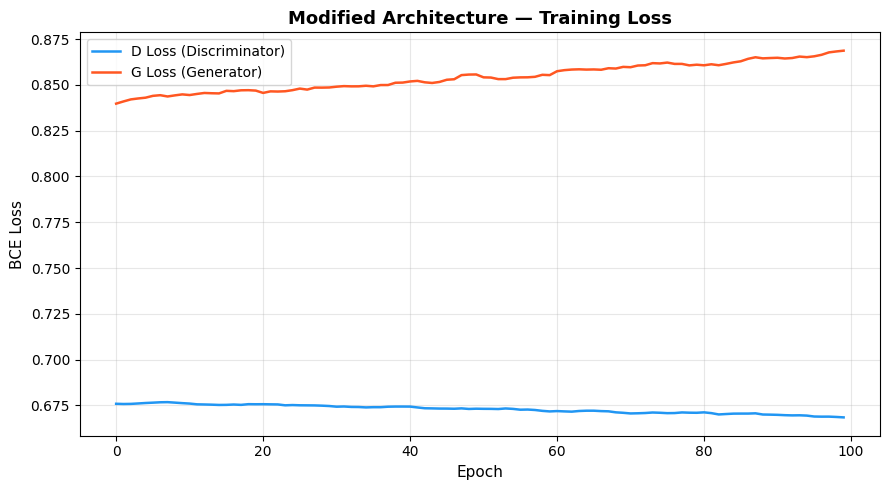

In [26]:
plot_history(hist_modif, 'Modified Architecture')

Dibandingkan dengan Baseline, training menunjukkan perbaikan yang cukup signifikan. Gap antara D-loss dan G-loss menjadi lebih kecil sehingga keduanya lebih seimbang. Selain itu, kedua loss juga relatif stabil selama proses training tanpa adanya lonjakan yang mengindikasikan ketidakstabilan atau mode collapse.

Perbaikan ini dipengaruhi oleh dua faktor utama. Pertama, penggunaan arsitektur convolutional yang lebih mampu menangkap pola spasial pada citra sehingga Generator dapat menghasilkan gambar yang lebih realistis. Kedua, penerapan label smoothing membuat Discriminator tidak menjadi terlalu overconfident, sehingga Generator tetap menerima umpan balik yang informatif selama training.

Meskipun demikian, G-loss yang sedikit meningkat pada epoch-epoch akhir menunjukkan bahwa Discriminator mulai lebih sulit untuk ditipu. Oleh karena itu, selanjutnya akan dilakukan tuning keseimbangan learning rate antara Generator dan Discriminator yang biasa disebut TTUR (Two Time-Scale Update Rule).

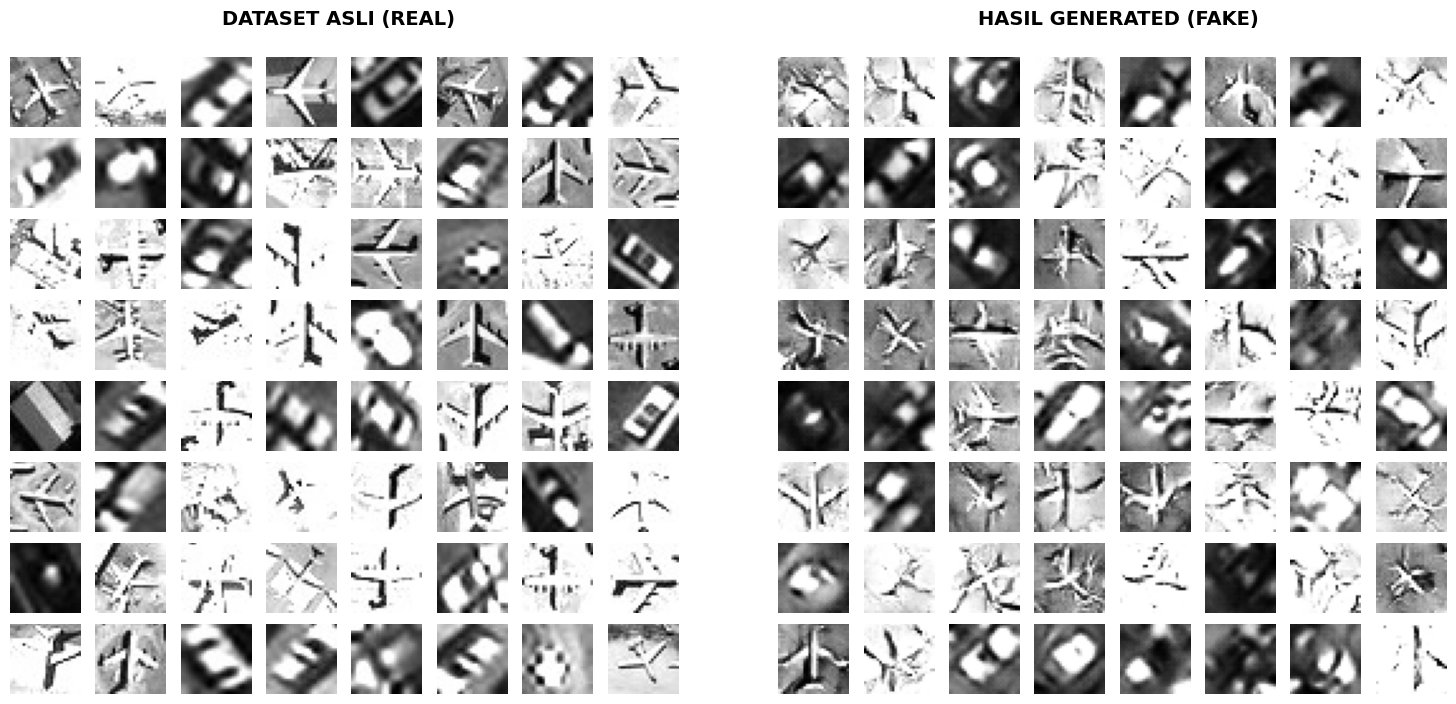

In [27]:
grid_size = 8
n_images = grid_size * grid_size 

idx = np.random.choice(len(X_test_img), n_images, replace=False)
real_imgs = ((X_test_img[idx] + 1) / 2.0).reshape(-1, IMG_SIZE, IMG_SIZE)
real_labels = tf.convert_to_tensor(y_test[idx].reshape(-1, 1), dtype=tf.int32)

noise = tf.random.normal((n_images, latent_dim))
generated = G_modif([noise, real_labels], training=False).numpy()
gen_imgs = ((generated + 1) / 2.0).reshape(-1, IMG_SIZE, IMG_SIZE)

fig, axes = plt.subplots(grid_size, grid_size * 2 + 1, figsize=(15, 7.5))

fig.text(0.24, 0.95, 'DATASET ASLI (REAL)', ha='center', va='center', fontsize=14, fontweight='bold')
fig.text(0.76, 0.95, 'HASIL GENERATED (FAKE)', ha='center', va='center', fontsize=14, fontweight='bold')

for i in range(n_images):
    row = i // grid_size
    col = i % grid_size
    
    ax_real = axes[row, col]
    ax_real.imshow(real_imgs[i], cmap='gray')
    ax_real.axis('off')
    
    ax_gen = axes[row, col + grid_size + 1]
    ax_gen.imshow(gen_imgs[i], cmap='gray')
    ax_gen.axis('off')

for row in range(grid_size):
    axes[row, grid_size].axis('off')

plt.subplots_adjust(top=0.90, bottom=0.05, left=0.02, right=0.98, hspace=0.15, wspace=0.15)
plt.show()

Terlihat gambar hasil generate modified model jauh lebih jelas dibandingkan baseline ketika kita bandingkan dengan data real. Didataset ini memang real image tidak terlalu jelas, namun Generator mampu menghasilkan gambar yang mirip dengan aslinya. 

### Hyperparameter Tuning - Learning Rate (TTUR)


In [ ]:
lr_configs = [
    (1e-4, 4e-4),   
    (2e-4, 2e-4),
    (5e-5, 4e-4),   
]

hasil_tuning = []
best_G, best_fid = None, float('inf')
best_hist = None

for g_lr, d_lr in lr_configs:
    print(f"\n=== g_lr={g_lr}, d_lr={d_lr} ===")
    G_tuned = build_modif_generator()
    D_tuned = build_modif_discriminator()
    hist_modif = train_gan(G_tuned, D_tuned, modif_ds,
                       g_lr=g_lr, d_lr=d_lr, epochs=100,
                       real_target=0.9,
                       name='Tuned Architecture')
    fid = eval_fid(G_tuned)
    print(f"FID = {fid:.2f}")
    hasil_tuning.append((g_lr, d_lr, round(fid, 2)))
    if fid < best_fid:
        best_fid = fid
        best_G = G_tuned
        best_hist = hist_modif



=== g_lr=0.0001, d_lr=0.0004 ===
Memulai training Tuned Architecture...


E0000 00:00:1782764232.646083      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodif_discriminator_1/dropout_8_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


[10/100] D: 0.574 | G: 1.283
[20/100] D: 0.626 | G: 1.069
[30/100] D: 0.578 | G: 1.205
[40/100] D: 0.588 | G: 1.185
[50/100] D: 0.591 | G: 1.196
[60/100] D: 0.601 | G: 1.148
[70/100] D: 0.618 | G: 1.117
[80/100] D: 0.627 | G: 1.073
[90/100] D: 0.636 | G: 1.046
[100/100] D: 0.641 | G: 1.016
FID = 79.58

=== g_lr=0.0002, d_lr=0.0002 ===
Memulai training Tuned Architecture...


E0000 00:00:1782764833.549309      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodif_discriminator_1/dropout_10_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


[10/100] D: 0.689 | G: 0.811
[20/100] D: 0.685 | G: 0.824
[30/100] D: 0.674 | G: 0.858
[40/100] D: 0.670 | G: 0.858
[50/100] D: 0.674 | G: 0.853
[60/100] D: 0.677 | G: 0.845
[70/100] D: 0.678 | G: 0.840
[80/100] D: 0.676 | G: 0.844
[90/100] D: 0.676 | G: 0.845
[100/100] D: 0.674 | G: 0.853
FID = 84.42

=== g_lr=5e-05, d_lr=0.0004 ===
Memulai training Tuned Architecture...


E0000 00:00:1782765434.817339      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodif_discriminator_1/dropout_12_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


[10/100] D: 0.415 | G: 1.975
[20/100] D: 0.540 | G: 1.499
[30/100] D: 0.533 | G: 1.380
[40/100] D: 0.482 | G: 1.631
[50/100] D: 0.465 | G: 1.733
[60/100] D: 0.479 | G: 1.733
[70/100] D: 0.491 | G: 1.664
[80/100] D: 0.498 | G: 1.665
[90/100] D: 0.503 | G: 1.631
[100/100] D: 0.506 | G: 1.591
FID = 96.45


In [29]:
tabel_tuned = pd.DataFrame(
    [(f"{g:.0e}", f"{d:.0e}", f) for g, d, f in hasil_tuning],
    columns=["g_lr", "d_lr", "FID"])
print("\n=== Hasil Tuning Learning Rate ===")
print(tabel_tuned.to_string(index=False))

fid_tuned = best_fid
print(f"\n>>> TTUR terbaik -> FID {fid_tuned:.2f}")


=== Hasil Tuning Learning Rate ===
 g_lr  d_lr   FID
1e-04 4e-04 79.58
2e-04 2e-04 84.42
5e-05 4e-04 96.45

>>> TTUR terbaik -> FID 79.58


Dari hasil tuning, konfigurasi TTUR (1e-4, 4e-4) menghasilkan nilai FID terendah sebesar 79.58, yang menunjukkan bahwa penggunaan learning rate Discriminator yang lebih tinggi daripada Generator mampu meningkatkan kualitas gambar yang dihasilkan. Pada konfigurasi ini, Discriminator dapat memberikan umpan balik yang lebih baik kepada Generator tanpa menjadi terlalu dominan. Sebaliknya, konfigurasi (5e-5, 4e-4) menghasilkan nilai FID tertinggi sebesar 96.45, yang mengindikasikan bahwa perbedaan learning rate yang terlalu besar menyebabkan Generator kesulitan mengikuti proses pembelajaran Discriminator sehingga kualitas gambar yang dihasilkan menurun.

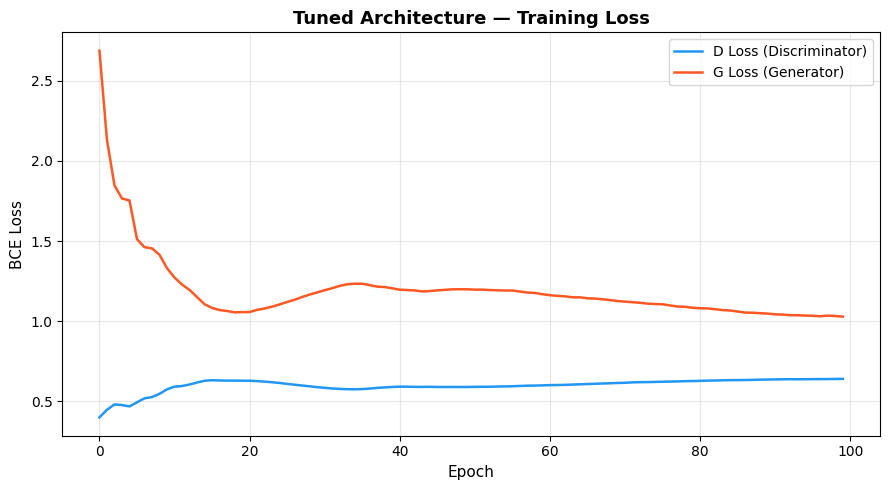

In [30]:
plot_history(best_hist, 'Tuned Architecture')

Grafik menunjukkan proses training yang stabil dan seimbang. Dengan penerapan TTUR, Discriminator belajar sedikit lebih cepat dibandingkan Generator sehingga dapat memberikan umpan balik yang lebih baik tanpa menjadi terlalu dominan.

Dibandingkan model modifikasi tanpa TTUR, tren G-loss pada epoch akhir terlihat lebih terkendali. Meskipun masih terjadi sedikit kenaikan, peningkatannya tidak terlalu signifikan dan tidak menunjukkan ketidakseimbangan yang serius antara Generator dan Discriminator. Hal ini mengindikasikan bahwa TTUR berhasil menjaga stabilitas proses pembelajaran keduanya.

Secara keseluruhan, hasil ini menunjukkan bahwa kombinasi arsitektur convolutional, label smoothing, dan TTUR menghasilkan proses training yang paling stabil sekaligus memberikan kualitas generasi terbaik, yang juga tercermin dari nilai FID terendah yang diperoleh.

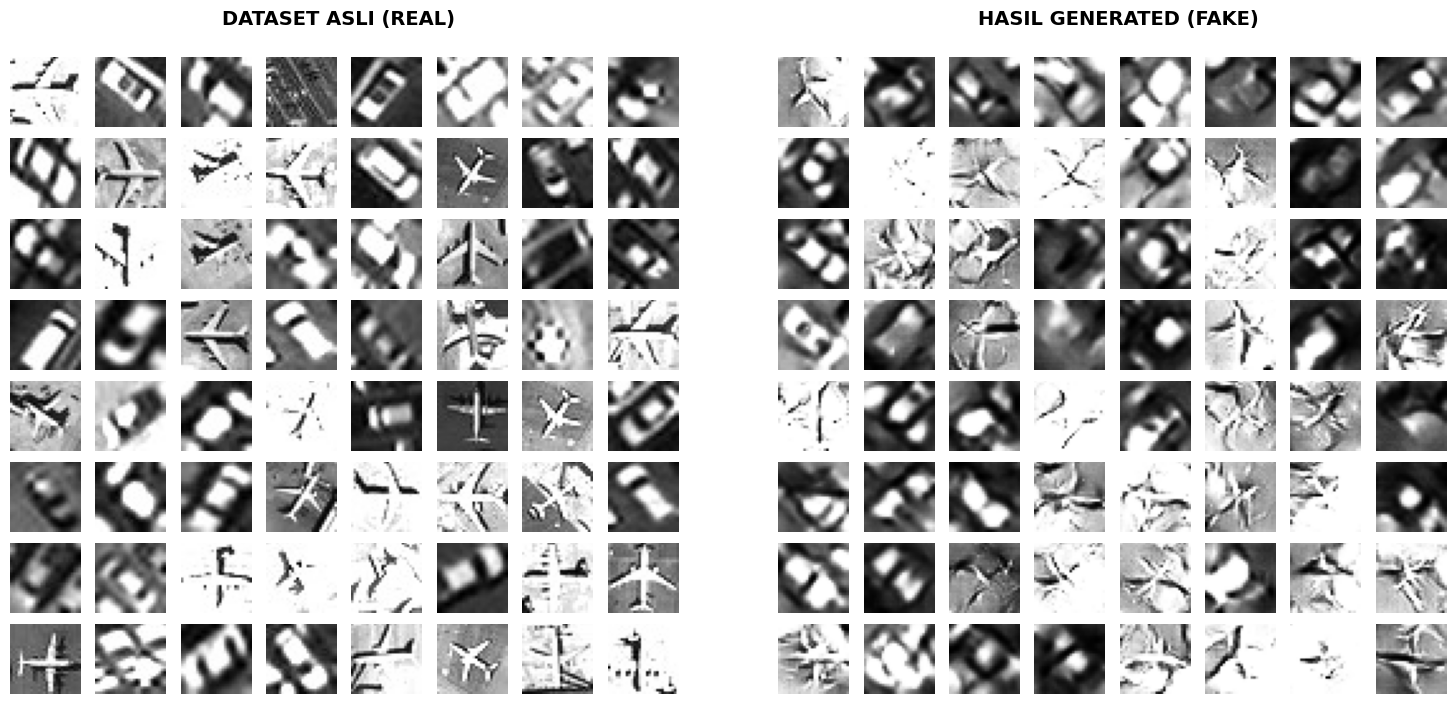

In [31]:
grid_size = 8
n_images = grid_size * grid_size 

idx = np.random.choice(len(X_test_img), n_images, replace=False)
real_imgs = ((X_test_img[idx] + 1) / 2.0).reshape(-1, IMG_SIZE, IMG_SIZE)
real_labels = tf.convert_to_tensor(y_test[idx].reshape(-1, 1), dtype=tf.int32)

noise = tf.random.normal((n_images, latent_dim))
generated = best_G([noise, real_labels], training=False).numpy()
gen_imgs = ((generated + 1) / 2.0).reshape(-1, IMG_SIZE, IMG_SIZE)

fig, axes = plt.subplots(grid_size, grid_size * 2 + 1, figsize=(15, 7.5))

fig.text(0.24, 0.95, 'DATASET ASLI (REAL)', ha='center', va='center', fontsize=14, fontweight='bold')
fig.text(0.76, 0.95, 'HASIL GENERATED (FAKE)', ha='center', va='center', fontsize=14, fontweight='bold')

for i in range(n_images):
    row = i // grid_size
    col = i % grid_size
    
    ax_real = axes[row, col]
    ax_real.imshow(real_imgs[i], cmap='gray')
    ax_real.axis('off')
    
    ax_gen = axes[row, col + grid_size + 1]
    ax_gen.imshow(gen_imgs[i], cmap='gray')
    ax_gen.axis('off')

for row in range(grid_size):
    axes[row, grid_size].axis('off')

plt.subplots_adjust(top=0.90, bottom=0.05, left=0.02, right=0.98, hspace=0.15, wspace=0.15)
plt.show()

Gambar hasil generate model tuning tampak sedikit lebih baik dibandingkan model modification dengan lr yang seimbang antara generator dan discriminator. Hal ini juga tercermin dari nilai FID yang lebih rendah.

In [35]:
ringkasan = pd.DataFrame([
    ("Baseline Model", round(fid_baseline, 2)),
    ("Modified Model", round(fid_modif, 2)),
    ("Modified + Tuned Model", round(fid_tuned, 2)),
], columns=["Model", "FID"])
ringkasan

,Model,FID
0,Baseline Model,215.79
1,Modified Model,84.39
2,Modified + Tuned Model,79.58


Dari tabel terlihat jelas perbandingan FID antara baseline model, modified model, dan modified & tuned model. FID terendah sebesar 79.58 dihasilkan oleh model cDCGAN dengan label smoothing dan learning rate 1e-04 untuk Generator serta 4e-04 untuk Discriminator. Hasil ini menunjukkan bahwa kombinasi modifikasi arsitektur, penerapan label smoothing, dan tuning learning rate melalui TTUR mampu meningkatkan kualitas citra yang dihasilkan serta menghasilkan distribusi data yang lebih mendekati data real dibandingkan konfigurasi lainnya untuk dataset ini.